In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.listdir('/content/drive/MyDrive/Colab')

['placement_dataset.csv',
 'placement_predict_50k Dataset (1) (1).csv',
 'placement_predict_50k_adjusted.csv',
 'age_insurance.csv',
 'simple_placement_dataset.csv',
 'movies_dataset(1).csv',
 'WineQT.csv',
 'WineQT_Feature_Engineered.csv',
 'placement_predict_50k_adjusted (1).csv',
 'student_data.csv',
 'xgboost_lightgbm_shap_student_dataset.csv',
 'iris_dataset.csv',
 'breast_cancer_classification_dataset (1).csv',
 'mall_customers_clustering_dataset.csv',
 'digits_pca_tsne_umap_dataset.csv',
 'isolation_forest_dataset.csv',
 'socioeconomic_profiling_dataset.csv',
 'ml_cross_validation_calibration_dataset.csv',
 'hyperparameter_tuning_dataset.csv',
 'evaluation_threshold_calibration_dataset.csv',
 'student_performance.csv',
 'student_performance_mlops.csv']

In [3]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab/placement_dataset.csv')

LOADING DATASET

First 5 rows:
   study_hours  attendance  previous_score  assignments_completed  \
0          3.6        83.9            45.7                      6   
1          7.7        58.8            89.6                      3   
2          6.1        62.3            67.8                      7   
3          5.2        95.4            85.5                      6   
4          2.1        82.3            57.6                      7   

   sleep_hours  internet_access  extracurricular  final_score  pass  
0          8.1                1                1         65.9     1  
1          4.6                0                1         67.7     1  
2          8.2                0                1         72.1     1  
3          4.6                1                1         79.9     1  
4          6.0                1                1         63.5     1  

Dataset shape:
(200, 9)

Missing values:
study_hours              0
attendance               0
previous_score           0
assignments

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/m


Baseline CV Scores:
[1.   0.95 0.95 0.95 0.95 0.95 0.95 0.95 0.95 0.9 ]

Tuned Model CV Scores:
[1.   1.   0.95 0.95 0.95 0.95 0.95 0.95 0.95 0.95]

Baseline Mean Accuracy:
0.95

Tuned Mean Accuracy:
0.9599999999999997

STATISTICAL SIGNIFICANCE TEST

Baseline scores:
[1.   0.95 0.95 0.95 0.95 0.95 0.95 0.95 0.95 0.9 ]

Tuned scores:
[1.   1.   0.95 0.95 0.95 0.95 0.95 0.95 0.95 0.95]

T-statistic:
-1.4999999999999998

P-value:
0.16785065605707492

STATISTICAL TEST RESULT
The difference is NOT statistically significant.
P-value is greater than or equal to 0.05.

MODEL COMPARISON
Baseline Test Accuracy : 0.925
Grid Search Accuracy   : 0.95
Random Search Accuracy : 0.95


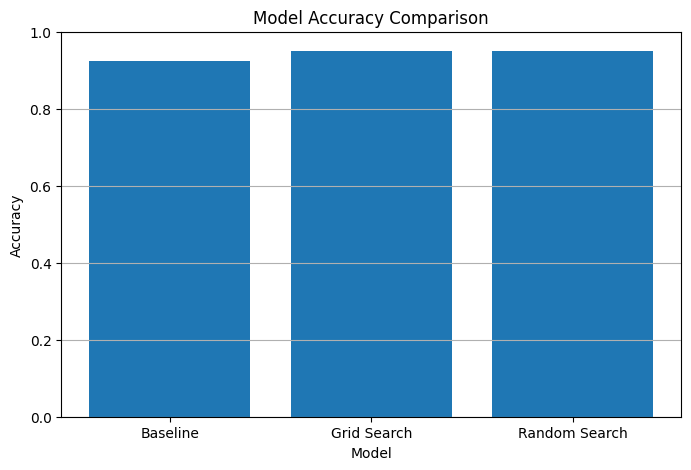

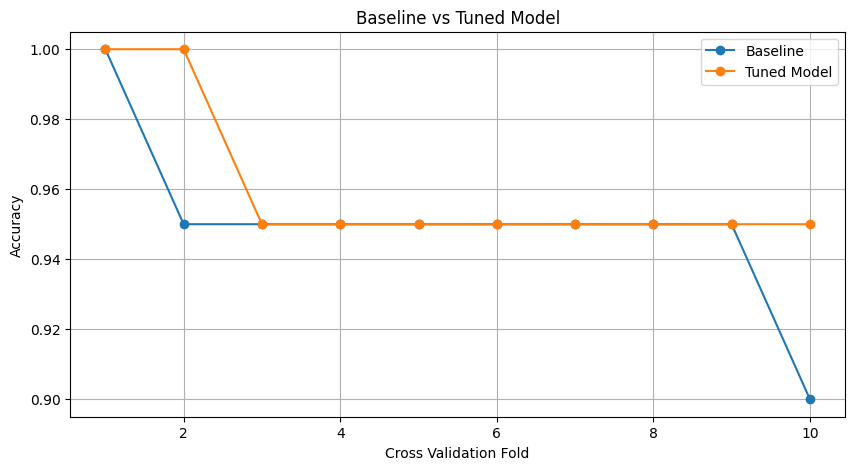


FINAL SUMMARY

Baseline Accuracy: 0.925
Grid Search Accuracy: 0.95
Random Search Accuracy: 0.95

Baseline Mean CV: 0.95
Tuned Mean CV: 0.96

T-statistic: -1.5
P-value: 0.167851

Project completed!


In [5]:
# ============================================================
# HYPERPARAMETER TUNING AND STATISTICAL SIGNIFICANCE
# MACHINE LEARNING PROJECT
#
# Project:
# Student Performance Prediction
#
# Techniques:
# 1. GridSearchCV
# 2. RandomizedSearchCV
# 3. Cross Validation
# 4. Statistical Significance Test
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from scipy.stats import ttest_rel


# ============================================================
# 1. LOAD DATASET
# ============================================================

print("=" * 60)
print("LOADING DATASET")
print("=" * 60)

df = pd.read_csv('/content/drive/MyDrive/Colab/student_performance.csv')

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nMissing values:")
print(df.isnull().sum())


# ============================================================
# 2. DEFINE FEATURES AND TARGET
# ============================================================

features = [
    "study_hours",
    "attendance",
    "previous_score",
    "assignments_completed",
    "sleep_hours",
    "internet_access",
    "extracurricular"
]

X = df[features]

y = df["pass"]


# ============================================================
# 3. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ============================================================
# 4. BASELINE RANDOM FOREST
# ============================================================

print("\n" + "=" * 60)
print("BASELINE MODEL")
print("=" * 60)

baseline_model = RandomForestClassifier(
    random_state=42
)

baseline_model.fit(
    X_train,
    y_train
)

baseline_prediction = baseline_model.predict(
    X_test
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_prediction
)

print(
    "Baseline Accuracy:",
    baseline_accuracy
)


# ============================================================
# 5. GRID SEARCH
# ============================================================

print("\n" + "=" * 60)
print("GRID SEARCH")
print("=" * 60)

param_grid = {

    "n_estimators": [
        50,
        100,
        150,
        200
    ],

    "max_depth": [
        3,
        5,
        10,
        15,
        None
    ],

    "min_samples_split": [
        2,
        5,
        10
    ],

    "min_samples_leaf": [
        1,
        2,
        4
    ]
}


grid_search = GridSearchCV(

    estimator=RandomForestClassifier(
        random_state=42
    ),

    param_grid=param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)


grid_search.fit(
    X_train,
    y_train
)


print("\nBest Parameters:")

print(
    grid_search.best_params_
)


print("\nBest Cross Validation Accuracy:")

print(
    grid_search.best_score_
)


# Test optimized model

grid_model = grid_search.best_estimator_

grid_prediction = grid_model.predict(
    X_test
)

grid_accuracy = accuracy_score(
    y_test,
    grid_prediction
)


print("\nGrid Search Test Accuracy:")

print(
    grid_accuracy
)


# ============================================================
# 6. RANDOMIZED SEARCH
# ============================================================

print("\n" + "=" * 60)
print("RANDOMIZED SEARCH")
print("=" * 60)


param_distribution = {

    "n_estimators": [
        50,
        100,
        150,
        200,
        250
    ],

    "max_depth": [
        3,
        5,
        10,
        15,
        20,
        None
    ],

    "min_samples_split": [
        2,
        5,
        10,
        15
    ],

    "min_samples_leaf": [
        1,
        2,
        4,
        6
    ],

    "max_features": [
        "sqrt",
        "log2"
    ]
}


random_search = RandomizedSearchCV(

    estimator=RandomForestClassifier(
        random_state=42
    ),

    param_distributions=param_distribution,

    n_iter=20,

    cv=5,

    scoring="accuracy",

    random_state=42,

    n_jobs=-1
)


random_search.fit(
    X_train,
    y_train
)


print("\nBest Parameters:")

print(
    random_search.best_params_
)


print("\nBest Cross Validation Accuracy:")

print(
    random_search.best_score_
)


# Test optimized model

random_model = random_search.best_estimator_

random_prediction = random_model.predict(
    X_test
)

random_accuracy = accuracy_score(
    y_test,
    random_prediction
)


print("\nRandom Search Test Accuracy:")

print(
    random_accuracy
)


# ============================================================
# 7. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        random_prediction
    )
)


# ============================================================
# 8. CROSS VALIDATION
# ============================================================

print("\n" + "=" * 60)
print("CROSS VALIDATION")
print("=" * 60)


cv = StratifiedKFold(

    n_splits=10,

    shuffle=True,

    random_state=42
)


# Baseline scores

baseline_scores = cross_val_score(

    RandomForestClassifier(
        random_state=42
    ),

    X,

    y,

    cv=cv,

    scoring="accuracy"
)


# Tuned model scores

tuned_scores = cross_val_score(

    random_model,

    X,

    y,

    cv=cv,

    scoring="accuracy"
)


print("\nBaseline CV Scores:")

print(
    baseline_scores
)


print("\nTuned Model CV Scores:")

print(
    tuned_scores
)


print("\nBaseline Mean Accuracy:")

print(
    baseline_scores.mean()
)


print("\nTuned Mean Accuracy:")

print(
    tuned_scores.mean()
)


# ============================================================
# 9. STATISTICAL SIGNIFICANCE TEST
# ============================================================

print("\n" + "=" * 60)
print("STATISTICAL SIGNIFICANCE TEST")
print("=" * 60)


# Paired t-test

t_statistic, p_value = ttest_rel(

    baseline_scores,

    tuned_scores
)


print("\nBaseline scores:")
print(baseline_scores)

print("\nTuned scores:")
print(tuned_scores)

print("\nT-statistic:")
print(t_statistic)

print("\nP-value:")
print(p_value)


# ============================================================
# 10. INTERPRETATION
# ============================================================

alpha = 0.05

print("\n" + "=" * 60)
print("STATISTICAL TEST RESULT")
print("=" * 60)


if p_value < alpha:

    print(
        "The difference is statistically significant."
    )

    print(
        "P-value is less than 0.05."
    )

else:

    print(
        "The difference is NOT statistically significant."
    )

    print(
        "P-value is greater than or equal to 0.05."
    )


# ============================================================
# 11. MODEL COMPARISON
# ============================================================

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)


print(
    "Baseline Test Accuracy :",
    baseline_accuracy
)

print(
    "Grid Search Accuracy   :",
    grid_accuracy
)

print(
    "Random Search Accuracy :",
    random_accuracy
)


# ============================================================
# 12. VISUALIZE RESULTS
# ============================================================

models = [
    "Baseline",
    "Grid Search",
    "Random Search"
]

accuracies = [

    baseline_accuracy,

    grid_accuracy,

    random_accuracy

]


plt.figure(
    figsize=(8, 5)
)


plt.bar(
    models,
    accuracies
)


plt.ylabel(
    "Accuracy"
)


plt.xlabel(
    "Model"
)


plt.title(
    "Model Accuracy Comparison"
)


plt.ylim(
    0,
    1
)


plt.grid(
    axis="y"
)


plt.show()


# ============================================================
# 13. CROSS VALIDATION SCORE VISUALIZATION
# ============================================================

plt.figure(
    figsize=(10, 5)
)


plt.plot(

    range(1, 11),

    baseline_scores,

    marker="o",

    label="Baseline"

)


plt.plot(

    range(1, 11),

    tuned_scores,

    marker="o",

    label="Tuned Model"

)


plt.xlabel(
    "Cross Validation Fold"
)


plt.ylabel(
    "Accuracy"
)


plt.title(
    "Baseline vs Tuned Model"
)


plt.legend()


plt.grid()


plt.show()


# ============================================================
# 14. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print(
    "\nBaseline Accuracy:",
    round(
        baseline_accuracy,
        4
    )
)

print(
    "Grid Search Accuracy:",
    round(
        grid_accuracy,
        4
    )
)

print(
    "Random Search Accuracy:",
    round(
        random_accuracy,
        4
    )
)

print(
    "\nBaseline Mean CV:",
    round(
        baseline_scores.mean(),
        4
    )
)

print(
    "Tuned Mean CV:",
    round(
        tuned_scores.mean(),
        4
    )
)

print(
    "\nT-statistic:",
    round(
        t_statistic,
        4
    )
)

print(
    "P-value:",
    round(
        p_value,
        6
    )
)

print("\nProject completed!")